**Lab2-DL: E1-emotions-building.ipynb** (BMED365) | Priority: 3 (optional)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab2-DL/notebooks/E1-emotions-building.ipynb)

# 😊 E1: CNN Classification of Facial Expressions - Part 1 (Building)

Updated: 2025-12-26, A. Lundervold

This notebook demonstrates how **Convolutional Neural Networks (CNN)** can be used to classify facial expressions and emotions.

---

## 🎯 Learning Objectives

| Goal | Description |
|-----|-------------|
| **Understand the dataset** | Learn about FER2013 and the 6 universal emotions |
| **Build CNN** | Construct a CNN architecture for image classification |
| **Understand pipeline** | Data → Preprocessing → Model → Training |
| **Medical connection** | See parallels to clinical image analysis |

---

## 📊 The FER2013 Dataset

**FER2013** (Facial Expression Recognition 2013) is a classic dataset for emotion recognition:

| Property | Value |
|----------|-------|
| **Number of images** | ~35,000 |
| **Resolution** | 48×48 pixels |
| **Format** | Grayscale |
| **Classes** | 6 emotions |

### The 6 Emotion Classes

| Class | Emotion | Emoji | Description |
|-------|---------|-------|-------------|
| 0 | **Disgust** | 🤢 | Discomfort, nausea, aversion |
| 1 | **Fear** | 😨 | Terror, anxiety, worry |
| 2 | **Happy** | 😊 | Happiness, satisfaction, smile |
| 3 | **Sad** | 😢 | Grief, low mood, melancholy |
| 4 | **Surprise** | 😲 | Astonishment, shock |
| 5 | **Neutral** | 😐 | No particular emotion |

> 💡 **Note:** Originally FER2013 had 7 classes, but **"Anger"** has been removed from this version.

---

## 🏥 Medical Relevance

Emotion recognition with CNN has several clinical applications:

| Application | Description |
|-------------|-------------|
| **Psychiatry** | Assess mood in patients with depression |
| **Neurology** | Detect facial expressions in Parkinson's disease |
| **Pain management** | Automatic pain assessment in patients |
| **Autism** | Support for emotion recognition |
| **Geriatrics** | Monitor dementia patients |

---

## 📐 Mathematical Formulation

In machine learning, we can express the emotion classification problem as:

$$\hat{y} = f(X, \theta)$$

Where:
- $\hat{y}$ = predicted emotion (0–5)
- $X$ = input face image (48×48 = 2304 pixel values)
- $\theta$ = model parameters (CNN weights)
- $f$ = CNN architecture (non-linear function)

This is **identical** to medical image analysis – just with different classes!

## 🔗 Comparison: Emotions vs Medical Images

| Aspect | Emotion Recognition | Medical Image Analysis |
|--------|---------------------|------------------------|
| **Input (X)** | 48×48 grayscale of faces | MRI, X-ray, CT |
| **Classes (y)** | 6 emotions | Disease conditions |
| **Challenges** | Micro-expressions, cultural differences | Anatomical variation |
| **Consequences of errors** | Psychological assessment | Medical diagnosis |
| **Data volume** | Thousands of images | Often limited |

**Common principles:**
- ✅ Both require **domain knowledge** for interpretation validation
- ✅ Both have problems with **imbalanced classes**
- ✅ Both need **robust models** that generalize
- ✅ Both have **ethical implications** (bias, privacy)

## 🔧 Environment Setup and Data Download

### Overview

This notebook requires:
1. **Python packages**: PyTorch, OpenCV, NumPy, etc.
2. **FER2013 dataset**: ~35,000 face images

---

### 📥 FER2013 Download - Detailed Guide

FER2013 is available via **Kaggle**. You have **three options**:

---

#### **Option A: Automatic download with Kaggle API (recommended)**

**Step 1:** Create a Kaggle account at [kaggle.com](https://www.kaggle.com)

**Step 2:** Generate API key:
1. Log in to Kaggle
2. Click on profile icon (top right) → **Settings**
3. Scroll down to **API** → **Create New API Token**
4. A file `kaggle.json` will be downloaded

**Step 3:** Place the API key:

```bash
# Mac/Linux
mkdir -p ~/.kaggle
mv ~/Downloads/kaggle.json ~/.kaggle/
chmod 600 ~/.kaggle/kaggle.json

# Windows (PowerShell)
mkdir $env:USERPROFILE\.kaggle
move $env:USERPROFILE\Downloads\kaggle.json $env:USERPROFILE\.kaggle\
```

**Step 4:** Run the code cell below - the dataset will be downloaded automatically!

---

#### **Option B: Manual download from Kaggle**

1. Go to: [kaggle.com/datasets/msambare/fer2013](https://www.kaggle.com/datasets/msambare/fer2013)
2. Click **Download** (requires login)
3. Extract the ZIP file
4. Place the contents in: `Lab2-DL/data/emotions/FER2013/`

Expected structure after extraction:
```
Lab2-DL/data/emotions/FER2013/
├── train/
│   ├── angry/     (empty in some versions)
│   ├── disgust/
│   ├── fear/
│   ├── happy/
│   ├── sad/
│   ├── surprise/
│   └── neutral/
└── test/
    ├── angry/
    ├── disgust/
    ...
```

---

#### **Option C: Google Colab with Kaggle Secrets**

In Colab, you can store Kaggle credentials as "Secrets":
1. Click the 🔑 icon in the left panel
2. Add:
   - `KAGGLE_USERNAME` = your username
   - `KAGGLE_KEY` = the API key from `kaggle.json`
3. Enable "Notebook access" for both

---

### ⚠️ Important about FER2013

- **License**: Non-commercial use
- **Privacy**: Images are anonymized (low resolution)
- **Quality**: Some images are mislabeled (realistic for medical data!)
- **Imbalance**: "Disgust" has the fewest images

In [1]:
import sys
import subprocess
import os

# Check if we are running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🚀 Running in Google Colab")
else:
    print("💻 Running in local environment")

💻 Running in local environment


In [2]:
if IN_COLAB:
    # Go to root folder
    os.chdir('/content')
    
    # Check current folder
    print(f"Current folder: {os.getcwd()}")
    
    # Check if the folder already exists
    if os.path.exists('BMED365-2026/Lab2-DL'):
        print("✅ BMED365-2026/Lab2-DL folder already exists!")
        
        # Check the contents
        print("\n📁 Contents of BMED365-2026/Lab2-DL folder:")
        try:
            result = subprocess.run(['ls', '-la', 'BMED365-2026/Lab2-DL'], 
                                  capture_output=True, text=True, check=True)
            print(result.stdout)
        except subprocess.CalledProcessError as e:
            print(f"❌ Could not list contents: {e}")
        
        # Check if it is a git repository
        if os.path.exists('BMED365-2026/Lab2-DL/.git'):
            print("\n✅ This is a git repository!")
            
            # Go into the folder and update
            os.chdir('BMED365-2026/Lab2-DL')
            print(f"📁 Changed to: {os.getcwd()}")
            
            # Try to update the repository
            try:
                result = subprocess.run(['git', 'pull'], 
                                      capture_output=True, text=True, check=True)
                print("✅ Repository updated!")
                print(result.stdout)
            except subprocess.CalledProcessError as e:
                print(f"⚠️ Could not update repository: {e}")
                print("But the folder exists and can be used!")
        else:
            print("⚠️ This does not look like a git repository")
            
    else:
        print("📂 Folder does not exist - trying git clone...")
        try:
            result = subprocess.run(['git', 'clone', 'https://github.com/arvidl/BMED365-2026.git'], 
                                  capture_output=True, text=True, check=True)
            print("✅ Repository cloned successfully!")
            print(result.stdout)
        except subprocess.CalledProcessError as e:
            print(f"❌ Git clone failed: {e}")
            print(f"Error output: {e.stderr}")

In [3]:
if IN_COLAB:
    !pip install opencv-python --quiet
    !pip install tqdm --quiet
    !pip install torchsummary --quiet

In [4]:
# Imports and setup with error handling
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import os
import random
import requests
import zipfile
from PIL import Image
import cv2
from tqdm import tqdm
import warnings
import pickle
from pathlib import Path
warnings.filterwarnings('ignore')

# ============================================================
# REPRODUCIBILITY SETTINGS
# ============================================================
# Set a fixed random seed for all random number generators
RANDOM_SEED = 42

def set_seed(seed=RANDOM_SEED):
    """
    Set random seeds for reproducibility across all libraries.
    This ensures the same results on each run.
    """
    # Python's built-in random
    random.seed(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # PyTorch
    torch.manual_seed(seed)
    
    # PyTorch CUDA (GPU)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU
        
        # Make cuDNN deterministic (may slow down training slightly)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    
    # Set environment variable for hash seed (Python hash randomization)
    os.environ['PYTHONHASHSEED'] = str(seed)

# Apply reproducibility settings
set_seed(RANDOM_SEED)
print(f"🎲 Random seed set to {RANDOM_SEED} for reproducibility")

# ============================================================
# DEVICE CONFIGURATION
# ============================================================
# Check if GPU or MPS is available and set device
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'🚀 GPU available: {torch.cuda.get_device_name(0)}')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print('🍎 Apple Silicon MPS available')
else:
    device = torch.device('cpu')
    print('💻 Using CPU')

print(f'Using device: {device}')

# ============================================================
# EMOTION CLASS DEFINITIONS
# ============================================================
EMOTIONS = {
    0: 'Disgust',
    1: 'Fear', 
    2: 'Happy',
    3: 'Sad',
    4: 'Surprise',
    5: 'Neutral'
}

EMOTIONS_LOWERCASE = {
    0: 'disgust',
    1: 'fear',
    2: 'happy', 
    3: 'sad',
    4: 'surprise',
    5: 'neutral'
}

EMOJIS = {
    0: '🤢',
    1: '😨',
    2: '😊',
    3: '😢',
    4: '😲',
    5: '😐'
}

print("✅ Emotion classes defined:")
for k, v in EMOTIONS.items():
    print(f"   {EMOJIS[k]} Class {k}: {v} ({EMOTIONS_LOWERCASE[k]})")

🎲 Random seed set to 42 for reproducibility
🍎 Apple Silicon MPS available
Using device: mps
✅ Emotion classes defined:
   🤢 Class 0: Disgust (disgust)
   😨 Class 1: Fear (fear)
   😊 Class 2: Happy (happy)
   😢 Class 3: Sad (sad)
   😲 Class 4: Surprise (surprise)
   😐 Class 5: Neutral (neutral)


## 1. Data Loading and Preparation

### 📊 FER2013 Dataset - Details

**FER2013** (Facial Expression Recognition 2013) is a reference dataset for emotion recognition:

| Property | Value |
|----------|-------|
| **Total images** | ~35,887 |
| **Resolution** | 48×48 pixels |
| **Color space** | Grayscale (1 channel) |
| **Classes** | 6 emotions |
| **Training** | ~28,709 images |
| **Test** | ~7,178 images |

---

### The 6 Emotion Classes

```
┌─────────┬─────────────────┬───────┐
│ Class   │ Emotion         │ Emoji │
├─────────┼─────────────────┼───────┤
│    0    │ Disgust         │  🤢   │
│    1    │ Fear            │  😨   │
│    2    │ Happy           │  😊   │
│    3    │ Sad             │  😢   │
│    4    │ Surprise        │  😲   │
│    5    │ Neutral         │  😐   │
└─────────┴─────────────────┴───────┘
```

### Class Imbalance (typical for FER2013)

```
                                      Number of images (approx.)
Happy       😊 ████████████████████████████████████  7,215
Neutral     😐 █████████████████████████            4,965
Sad         😢 ████████████████████████             4,830
Fear        😨 ████████████████████                 4,097
Surprise    😲 ████████████████████                 3,171
Disgust     🤢 ███                                   547
```

> ⚠️ **Class imbalance:** "Disgust" has significantly fewer images. This is common in clinical datasets and affects model training!

---

### Dataset Structure After Organization

```
Lab2-DL/data/emotions/FER2013/
├── train/              # ~80% of data
│   ├── disgust/
│   ├── fear/
│   ├── happy/
│   ├── sad/
│   ├── surprise/
│   └── neutral/
├── val/                # ~15% of data (from train)
│   └── ... (same structure)
└── test/               # ~5% of data
    └── ... (same structure)
```

In [5]:
def fetch_fer2013_dataset():
    """
    Fetch FER2013 dataset from Kaggle.
    
    Uses Kaggle Python API for more robust downloading.
    """
    print("📥 Fetching FER2013 dataset")
    print("=" * 50)
    
    data_dir = Path("../data/emotions/FER2013")
    data_dir.mkdir(parents=True, exist_ok=True)
    
    # Check if data already exists
    existing_images = list(data_dir.glob("**/*.png")) + list(data_dir.glob("**/*.jpg"))
    
    if len(existing_images) > 100:  # More than 100 images = probably complete
        print(f"✅ Data already exists: {len(existing_images)} images")
        return True
    
    # Try to download from Kaggle
    try:
        if IN_COLAB:
            # In Colab: Install kaggle and use Secrets
            import subprocess
            subprocess.run(['pip', 'install', 'kaggle', '--quiet'], check=True)
            
            from google.colab import userdata
            try:
                os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
                os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
                print("✅ Kaggle credentials loaded from Colab Secrets!")
            except Exception as e:
                print(f"❌ Could not load Kaggle Secrets: {e}")
                print("\n📋 Instructions:")
                print("1. Click the 🔑 icon in the left panel")
                print("2. Add KAGGLE_USERNAME and KAGGLE_KEY")
                print("3. Enable 'Notebook access'")
                return False
        
        # Try Kaggle Python API first
        try:
            from kaggle.api.kaggle_api_extended import KaggleApi
            
            print("🔄 Using Kaggle Python API...")
            api = KaggleApi()
            api.authenticate()
            
            # Download the dataset
            print("📥 Downloading FER2013 (this may take a few minutes)...")
            api.dataset_download_files(
                'msambare/fer2013',
                path=str(data_dir),
                unzip=True
            )
            print("✅ Download complete!")
            
        except ImportError:
            # Fallback to CLI
            print("⚠️ Kaggle Python API not available, trying CLI...")
            
            import subprocess
            result = subprocess.run([
                "kaggle", "datasets", "download",
                "-d", "msambare/fer2013",
                "-p", str(data_dir), "--unzip"
            ], capture_output=True, text=True)
            
            if result.returncode != 0:
                raise Exception(f"CLI error: {result.stderr}")
            print("✅ Download complete via CLI!")
        
        # Verify download
        downloaded_images = list(data_dir.glob("**/*.png")) + list(data_dir.glob("**/*.jpg"))
        if len(downloaded_images) > 100:
            print(f"✅ Verified: {len(downloaded_images)} images downloaded")
            return True
        else:
            print(f"⚠️ Only {len(downloaded_images)} images found - check the download")
            return False
            
    except Exception as e:
        print(f"❌ Automatic download failed: {e}")
        print("\n" + "=" * 50)
        print("📋 MANUAL DOWNLOAD:")
        print("=" * 50)
        print("1. Go to: https://www.kaggle.com/datasets/msambare/fer2013")
        print("2. Log in to Kaggle")
        print("3. Click 'Download'")
        print(f"4. Extract to: {data_dir.absolute()}")
        print("\nAfter manual download, run this cell again!")
        return False


In [6]:
%%time
# Fetch data (if not already downloaded)
success = fetch_fer2013_dataset()

📥 Fetching FER2013 dataset
✅ Data already exists: 35887 images
CPU times: user 116 ms, sys: 60.7 ms, total: 177 ms
Wall time: 203 ms


In [7]:
def organize_fer2013_dataset():
    """
    Organize FER2013 dataset into train/val/test folders
    """
    print("🔧 Organizing FER2013 dataset")
    print("=" * 50)
    
    data_dir = Path("../data/emotions/FER2013")
    
    # Emotion classes
    emotion_classes = {
        0: 'disgust', 
        1: 'fear',
        2: 'happy',
        3: 'sad',
        4: 'surprise',
        5: 'neutral'
    }
    
    # Create subfolders for all splits and emotion classes
    for split in ['train', 'val', 'test']:
        for emotion in emotion_classes.values():
            (data_dir / split / emotion).mkdir(parents=True, exist_ok=True)
    
    # Check if data is already organized
    val_images = list((data_dir / "val").glob("**/*.png")) + list((data_dir / "val").glob("**/*.jpg"))
    
    if val_images:
        print("✅ Data already organized!")
        return True
    
    # If val folder is empty, move images from train
    print("🔄 Val folder is empty - moving images from train...")
    
    total_moved = 0
    
    # Go through each emotion class
    for emotion in emotion_classes.values():
        train_emotion_dir = data_dir / "train" / emotion
        val_emotion_dir = data_dir / "val" / emotion
        
        # Find all images in this emotion class
        emotion_images = list(train_emotion_dir.glob("*.png")) + list(train_emotion_dir.glob("*.jpg"))
        
        if not emotion_images:
            print(f"  ⚠️ {emotion}: No images found in train")
            continue
            
        # Move 15% of images to val
        val_count = int(len(emotion_images) * 0.15)
        
        if val_count > 0:
            print(f"  {emotion}: {len(emotion_images)} images → moving {val_count} to val")
            
            # Move the images
            moved_count = 0
            for image_path in emotion_images:
                if moved_count >= val_count:
                    break
                    
                # Create new path in val folder
                val_path = val_emotion_dir / image_path.name
                
                # Move the image
                try:
                    image_path.rename(val_path)
                    moved_count += 1
                    total_moved += 1
                except Exception as e:
                    print(f"⚠️ Could not move {image_path.name}: {e}")
        else:
            print(f"  {emotion}: {len(emotion_images)} images → none moved (too few images)")
    
    print(f"✅ Moved a total of {total_moved} images to val!")
    
    # Show statistics
    print("\n📊 New organization:")
    for split in ['train', 'val', 'test']:
        split_images = list((data_dir / split).glob("**/*.png")) + list((data_dir / split).glob("**/*.jpg"))
        print(f"  {split}: {len(split_images)} images")
        
        # Show per emotion class
        for emotion in emotion_classes.values():
            emotion_images = list((data_dir / split / emotion).glob("*.png")) + list((data_dir / split / emotion).glob("*.jpg"))
            if emotion_images:
                print(f"    {emotion}: {len(emotion_images)} images")
    
    return True

In [8]:
# Organize data (if not already organized)
# Check if data exists before organizing (in case previous cell was skipped)
data_dir = Path("../data/emotions/FER2013")
if data_dir.exists() and any(data_dir.glob("**/*.jpg")) or any(data_dir.glob("**/*.png")):
    organize_fer2013_dataset()
else:
    print("⚠️ No data found. Please run the fetch_fer2013_dataset() cell first.")

🔧 Organizing FER2013 dataset
✅ Data already organized!


In [9]:
def check_fer2013_data():
    """Check if FER2013 data exists and is organized"""
    data_dir = Path("../data/emotions/FER2013")
    
    # Check if images exist
    existing_images = list(data_dir.glob("**/*.jpg")) + list(data_dir.glob("**/*.png"))
    
    if existing_images:
        print(f"✅ FER2013 data exists: {len(existing_images)} images")
        
        # Count images per split and emotion
        splits = ['train', 'val', 'test']
        emotions = ['anger', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
        
        for split in splits:
            print(f"\n{split.upper()}:")
            for emotion in emotions:
                count = len(list((data_dir / split / emotion).glob("*.jpg")) + 
                           list((data_dir / split / emotion).glob("*.png")))
                if count > 0:
                    print(f"  {emotion}: {count} images")
        
        return True
    else:
        print("❌ No FER2013 data found")
        return False

# Run check
data_ready = check_fer2013_data()

✅ FER2013 data exists: 35887 images

TRAIN:
  disgust: 371 images
  fear: 3483 images
  happy: 6133 images
  sad: 4106 images
  surprise: 2696 images
  neutral: 4221 images

VAL:
  disgust: 65 images
  fear: 614 images
  happy: 1082 images
  sad: 724 images
  surprise: 475 images
  neutral: 744 images

TEST:
  disgust: 111 images
  fear: 1024 images
  happy: 1774 images
  sad: 1247 images
  surprise: 831 images
  neutral: 1233 images


In [10]:
class EmotionDataset(Dataset):
    """Custom dataset for emotion classification"""
    
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('L')  # Grayscale
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

### 📸 Visualize Examples from Each Emotion Class

This cell shows examples from each of the 6 emotion classes. These are the same images used in **E2 (Training)** and **E3 (Evaluation)**.

📸 Emotion examples from FER2013
  🤢 Disgust     :   482 images
  😨 Fear        :  4507 images
  😊 Happy       :  7907 images
  😢 Sad         :  5353 images
  😲 Surprise    :  3527 images
  😐 Neutral     :  5454 images


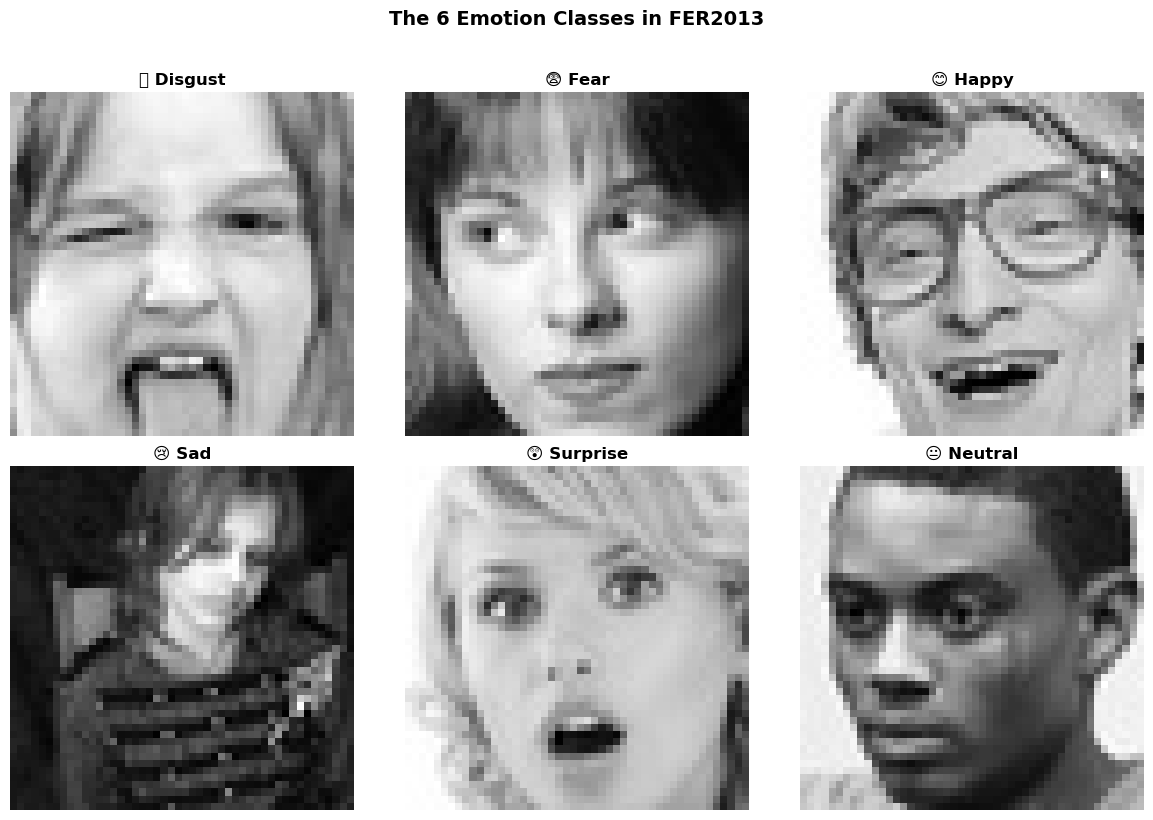


💾 Figure saved to: ../resources/fer2013_emotion_examples.png

💡 These emotion classes are used in:
   • E2-emotions-training.ipynb
   • E3-emotions-evaluation.ipynb


In [11]:
def visualize_emotion_examples():
    """
    Visualize examples from each emotion class.
    Uses fixed seed for reproducibility - same images shown each run.
    """
    # Reset seed for reproducible visualization
    set_seed(RANDOM_SEED)
    
    data_dir = Path("../data/emotions/FER2013")
    
    # Class names and emojis
    classes = {
        'disgust':  ('Disgust',   '🤢'),
        'fear':     ('Fear',      '😨'),
        'happy':    ('Happy',     '😊'),
        'sad':      ('Sad',       '😢'),
        'surprise': ('Surprise',  '😲'),
        'neutral':  ('Neutral',   '😐')
    }
    
    # Find images for each class
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    
    print("📸 Emotion examples from FER2013")
    print("=" * 50)
    
    for idx, (class_name, (display_name, emoji)) in enumerate(classes.items()):
        ax = axes[idx]
        
        # Search in train and test folders
        images = []
        for split in ['train', 'test']:
            split_dir = data_dir / split / class_name
            if split_dir.exists():
                images.extend(list(split_dir.glob("*.jpg")) + list(split_dir.glob("*.png")))
        
        if images:
            # Sort images for consistent ordering, then select reproducibly
            images = sorted(images, key=lambda x: x.name)
            # Use random.choice with seeded random for reproducibility
            img_path = random.choice(images[:min(100, len(images))])
            img = Image.open(img_path).convert('L')
            
            ax.imshow(np.array(img), cmap='gray')
            ax.set_title(f'{emoji} {display_name}', fontsize=12, fontweight='bold')
            ax.axis('off')
            
            print(f"  {emoji} {display_name:12s}: {len(images):>5} images")
        else:
            ax.text(0.5, 0.5, f'{emoji}\n{display_name}\n(no images)', 
                   ha='center', va='center', fontsize=10, transform=ax.transAxes)
            ax.axis('off')
            print(f"  {emoji} {display_name:12s}: ❌ No images found")
    
    plt.suptitle('The 6 Emotion Classes in FER2013', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Create output directory if it doesn't exist
    output_dir = Path('../resources')
    output_dir.mkdir(parents=True, exist_ok=True)
    
    output_path = output_dir / 'fer2013_emotion_examples.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n💾 Figure saved to: {output_path}")
    print("\n💡 These emotion classes are used in:")
    print("   • E2-emotions-training.ipynb")
    print("   • E3-emotions-evaluation.ipynb")

# Run visualization if data exists
if data_ready:
    visualize_emotion_examples()
else:
    print("⚠️ The dataset has not been downloaded yet.")
    print("   Run fetch_fer2013_dataset() first!")

In [12]:
def load_emotion_data(data_dir, test_size=0.2, val_size=0.2):
    """
    Load and split emotion dataset.
    
    For reproducibility:
    - File paths are sorted before splitting
    - train_test_split uses fixed random_state
    """
    # Emotion classes
    emotion_classes = {
        0: 'disgust', 
        1: 'fear',
        2: 'happy',
        3: 'sad',
        4: 'surprise',
        5: 'neutral'
    }
    
    # Collect all image paths and labels
    image_paths = []
    labels = []
    
    for split in ['train', 'val', 'test']:
        split_dir = os.path.join(data_dir, split)
        if os.path.exists(split_dir):
            for emotion_name in emotion_classes.values():
                emotion_dir = os.path.join(split_dir, emotion_name)
                if os.path.exists(emotion_dir):
                    # Sort filenames for consistent ordering across runs
                    filenames = sorted(os.listdir(emotion_dir))
                    for filename in filenames:
                        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                            image_paths.append(os.path.join(emotion_dir, filename))
                            # Find emotion index
                            emotion_idx = [k for k, v in emotion_classes.items() if v == emotion_name][0]
                            labels.append(emotion_idx)
    
    # Sort by path to ensure consistent ordering (important for reproducibility)
    sorted_indices = sorted(range(len(image_paths)), key=lambda i: image_paths[i])
    image_paths = [image_paths[i] for i in sorted_indices]
    labels = [labels[i] for i in sorted_indices]
    
    print(f"Total images found: {len(image_paths)}")
    print(f"Emotions: {list(emotion_classes.values())}")
    print(f"Images per emotion: {np.bincount(labels)}")
    
    # Split data with fixed random_state for reproducibility
    if len(set(labels)) > 1:  # Check if we have multiple classes
        X_train, X_temp, y_train, y_temp = train_test_split(
            image_paths, labels, test_size=test_size + val_size, 
            random_state=RANDOM_SEED, stratify=labels
        )
        
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=test_size/(test_size + val_size),
            random_state=RANDOM_SEED, stratify=y_temp
        )
    else:
        # Fallback if we only have one class
        X_train, X_val, X_test = image_paths, image_paths, image_paths
        y_train, y_val, y_test = labels, labels, labels
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test), list(emotion_classes.values())

In [13]:
# Data transformations
train_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize grayscale
])

val_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

print("✅ Data transformations defined!")

✅ Data transformations defined!


## 2. CNN Model for Emotion Recognition

In [14]:
class EmotionNet(nn.Module):
    """CNN for emosjonsklassifikasjon"""
    
    emotion_classes = {
        0: 'disgust', 
        1: 'fear',
        2: 'happy',
        3: 'sad',
        4: 'surprise',
        5: 'neutral'
    }
    
    def __init__(self, num_classes=len(emotion_classes), dropout_rate=0.5):
        super(EmotionNet, self).__init__()
        
        # Feature extraction layers
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),
            
            # Block 2  
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),
            
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),
        )
        
        # Adaptive pooling for ulike input-størrelser
        self.adaptive_pool = nn.AdaptiveAvgPool2d((3, 3))
        
        # Klassifikator
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        return x

### 🧠 Explanation of EmotionNet Architecture

**EmotionNet** is a CNN specifically designed for emotion recognition:

---

#### Architecture Overview

```
INPUT (48×48×1)        Grayscale face image
      │
      ▼
┌─────────────────┐
│  BLOCK 1        │    Conv2d(1→32) → BatchNorm → ReLU → MaxPool → Dropout
│  32 filters     │    Output: 24×24×32
└─────────────────┘
      │
      ▼
┌─────────────────┐
│  BLOCK 2        │    Conv2d(32→64) → BatchNorm → ReLU → MaxPool → Dropout
│  64 filters     │    Output: 12×12×64
└─────────────────┘
      │
      ▼
┌─────────────────┐
│  BLOCK 3        │    Conv2d(64→128) → BatchNorm → ReLU → MaxPool → Dropout
│  128 filters    │    Output: 6×6×128
└─────────────────┘
      │
      ▼
┌─────────────────┐
│  BLOCK 4        │    Conv2d(128→256) → BatchNorm → ReLU → MaxPool → Dropout
│  256 filters    │    Output: 3×3×256
└─────────────────┘
      │
      ▼
┌─────────────────┐
│  CLASSIFIER     │    Flatten → FC(2304→512) → FC(512→256) → FC(256→6)
│  6 classes      │
└─────────────────┘
      │
      ▼
OUTPUT: Probabilities for each emotion
        [Disgust, Fear, Happy, Sad, Surprise, Neutral]
```

---

#### What Does Each Layer Learn?

| Layer | What it learns | Medical parallel |
|-------|----------------|------------------|
| **Block 1** | Edges, lines | Contours in X-rays |
| **Block 2** | Simple shapes | Anatomical structures |
| **Block 3** | Facial features (eyes, mouth) | Organs, lesions |
| **Block 4** | Complex patterns | Pathological patterns |

---

#### Regularization Techniques

| Technique | What it does | Why important |
|-----------|--------------|---------------|
| **BatchNorm** | Normalizes activations | Stabilizes training |
| **Dropout2d** | Turns off random channels | Prevents overfitting |
| **Dropout** | Turns off random neurons | Robustness |

---

#### Parameter Distribution

```
Layer                    Parameters
─────────────────────────────────────
Conv Block 1:                 896
Conv Block 2:               18,624
Conv Block 3:               74,112
Conv Block 4:              295,424
Classifier:             1,317,382
─────────────────────────────────────
TOTAL:                 ~1,706,438
```

> 💡 **Note:** Most parameters (77%) are in the classifier, not in the convolutions!

## 3. Training Functions

In this section, we define the functions used to train the model.

### Training Loop

For each **epoch** (pass through the entire training dataset):

1. **Forward pass**: Compute predictions
2. **Loss calculation**: Compare with ground truth (Cross-Entropy Loss)
3. **Backward pass**: Compute gradients via backpropagation
4. **Update weights**: Adjust parameters (Adam optimizer)

```
┌─────────────────────────────────────────────────────────────────┐
│                     TRAINING LOOP                               │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│   for epoch in range(num_epochs):                               │
│       ┌─────────────────────────────────────────────────────┐   │
│       │  TRAINING                                           │   │
│       │  for batch in train_loader:                         │   │
│       │      1. Forward:  ŷ = model(X)                      │   │
│       │      2. Loss:     L = CrossEntropy(ŷ, y)            │   │
│       │      3. Backward: ∂L/∂θ                             │   │
│       │      4. Update:   θ = θ - α * ∂L/∂θ                 │   │
│       └─────────────────────────────────────────────────────┘   │
│       ┌─────────────────────────────────────────────────────┐   │
│       │  VALIDATION (no gradient update)                    │   │
│       │  for batch in val_loader:                           │   │
│       │      ŷ = model(X)                                   │   │
│       │      val_loss = CrossEntropy(ŷ, y)                  │   │
│       └─────────────────────────────────────────────────────┘   │
│                                                                 │
│   if val_loss doesn't improve → Early Stopping                  │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

### Cross-Entropy Loss for Multi-class

For emotion classification with 6 classes:

$$L = -\sum_{i=1}^{6} y_i \log(\hat{y}_i)$$

Where $y_i$ is the one-hot target and $\hat{y}_i$ is the predicted probability.

### 🎲 Reproducibility

The training process is made reproducible by:
- Setting `RANDOM_SEED = 42` at the start
- Using `set_seed()` before training
- Fixed generator for DataLoader shuffling
- Deterministic cuDNN operations (when using CUDA)

In [15]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train model for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(dataloader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

def validate_epoch(model, dataloader, criterion, device):
    """Validate model for one epoch"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

In [16]:
def train_model(model, train_loader, val_loader, num_epochs=50, learning_rate=0.001):
    """
    Train the complete model.
    
    For reproducibility, set_seed() should be called before this function.
    """
    # Reset seed at start of training for reproducibility
    set_seed(RANDOM_SEED)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0
    patience_counter = 0
    
    print("Starting training...")
    print("=" * 50)
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 30)
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
        
        # Update learning rate
        scheduler.step(val_loss)
        
        # Store metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), './modeller/best_emotion_model.pth')
        else:
            patience_counter += 1
            
        if patience_counter >= 10:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
    
    return {
        'train_losses': train_losses,
        'val_losses': val_losses, 
        'train_accs': train_accs,
        'val_accs': val_accs,
        'best_val_acc': best_val_acc
    }

## 4. Main Execution - Part 1

In [17]:
# Worker initialization function for reproducible DataLoader
def seed_worker(worker_id):
    """
    Seed function for DataLoader workers to ensure reproducibility.
    Each worker gets a deterministic seed based on the global seed and worker_id.
    """
    worker_seed = RANDOM_SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# Main execution with automatic setup
def main_part1():
    """Main execution part 1: Data loading and model setup"""
    
    # Reset seeds at start of main execution for reproducibility
    set_seed(RANDOM_SEED)
    
    print("😊 Facial Expression Classification with CNN - Part 1")
    print("=" * 60)
    
    # Set up data directories
    data_dir = "../data/emotions/FER2013"
    
    # Check if data exists
    if not os.path.exists(data_dir) or len(os.listdir(data_dir)) == 0:
        print("❌ Data directory not found or empty!")
        print("\n🔄 Trying automatic setup...")
        
        # Try automatic download
        success = fetch_fer2013_dataset()
        
        if not success:
            print("\n❌ Automatic setup failed!")
            print("\n📋 Manual download:")
            print("1. Go to: https://www.kaggle.com/datasets/msambare/fer2013")
            print("2. Download 'fer2013.zip'")
            print("3. Extract to '../data/emotions/' folder")
            return None, None, None, None, None
    else:
        print("✅ Data directory found!")
    
    # Load data
    print("\n📂 Loading data...")
    (X_train, y_train), (X_val, y_val), (X_test, y_test), class_names = load_emotion_data(data_dir)
    
    # Create datasets
    print("\n🔧 Creating training, validation, and test datasets...")
    train_dataset = EmotionDataset(X_train, y_train, train_transform)
    val_dataset = EmotionDataset(X_val, y_val, val_transform)
    test_dataset = EmotionDataset(X_test, y_test, val_transform)
    
    # Create generator with fixed seed for reproducible shuffling
    generator = torch.Generator()
    generator.manual_seed(RANDOM_SEED)
    
    # Create data loaders with reproducibility settings
    # - generator: ensures reproducible shuffling
    # - worker_init_fn: ensures workers have reproducible random states
    train_loader = DataLoader(
        train_dataset, 
        batch_size=32, 
        shuffle=True, 
        num_workers=0,
        generator=generator,
        worker_init_fn=seed_worker
    )
    val_loader = DataLoader(
        val_dataset, 
        batch_size=32, 
        shuffle=False, 
        num_workers=0
    )
    test_loader = DataLoader(
        test_dataset, 
        batch_size=32, 
        shuffle=False, 
        num_workers=0
    )
    
    print(f"✅ Data loading successful!")
    print(f"Training: {len(train_dataset)} images")
    print(f"Validation: {len(val_dataset)} images") 
    print(f"Test: {len(test_dataset)} images")
    print(f"🎲 DataLoaders configured with seed {RANDOM_SEED} for reproducibility")
    
    # Build model
    print("\n🏗️ Building model...")
    # Reset seed before model initialization for reproducible weights
    set_seed(RANDOM_SEED)
    model = EmotionNet(num_classes=len(class_names)).to(device)
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    return model, train_loader, val_loader, test_loader, class_names



In [18]:
# Run main execution
model, train_loader, val_loader, test_loader, class_names = main_part1()

😊 Facial Expression Classification with CNN - Part 1
✅ Data directory found!

📂 Loading data...
Total images found: 30934
Emotions: ['disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
Images per emotion: [ 547 5121 8989 6077 4002 6198]

🔧 Creating training, validation, and test datasets...
✅ Data loading successful!
Training: 18560 images
Validation: 6187 images
Test: 6187 images
🎲 DataLoaders configured with seed 42 for reproducibility

🏗️ Building model...
Model parameters: 1,701,830


In [19]:
# Show model structure
print("\n📊 Model Summary:")
print("=" * 50)

# Test the model with dummy input first
print("🧪 Testing model with dummy input...")
try:
    dummy_input = torch.randn(1, 1, 48, 48).to(device)
    with torch.no_grad():
        output = model(dummy_input)
    print(f"✅ Model test successful!")
    print(f"Input shape: {dummy_input.shape}")
    print(f"Output shape: {output.shape}")
    print(f"Output device: {output.device}")
except Exception as e:
    print(f"❌ Model test failed: {e}")

# Show model structure manually
print(f"\n📋 Model Details:")
print(f"Model: {model}")
print(f"Device: {device}")
print(f"Input size: (batch_size, 1, 48, 48)")
print(f"Output size: (batch_size, {len(class_names)})")

# Try torchsummary if the model works
try:
    from torchsummary import summary
    # Make sure the model is on CPU for torchsummary
    model_cpu = model.cpu()
    summary(model_cpu, input_size=(1, 48, 48))  # (channels, height, width)
    # Move the model back to the correct device
    model = model.to(device)
except ImportError:
    print("\n⚠️ torchsummary not available - install with: pip install torchsummary")
except Exception as e:
    print(f"\n⚠️ torchsummary failed: {e}")
    print("Using manual model display instead")


📊 Model Summary:
🧪 Testing model with dummy input...
✅ Model test successful!
Input shape: torch.Size([1, 1, 48, 48])
Output shape: torch.Size([1, 6])
Output device: mps:0

📋 Model Details:
Model: EmotionNet(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.25, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, 

## 📋 Summary of Part 1

In this notebook, we have:

| Step | Description | Status |
|------|-------------|--------|
| 1. **Environment setup** | Works both locally and in Colab | ✅ |
| 2. **FER2013 download** | Automatic via Kaggle API | ✅ |
| 3. **Dataset analysis** | 6 emotion classes | ✅ |
| 4. **CNN architecture** | EmotionNet with ~1.7M parameters | ✅ |
| 5. **Training functions** | Train/validate with early stopping | ✅ |
| 6. **Reproducibility** | Fixed seeds for consistent results | ✅ |

---

### 🎲 Reproducibility Features

This notebook is configured to produce **identical results on each run**:

| Component | Method |
|-----------|--------|
| **Python random** | `random.seed(42)` |
| **NumPy** | `np.random.seed(42)` |
| **PyTorch** | `torch.manual_seed(42)` |
| **CUDA/cuDNN** | Deterministic mode enabled |
| **Data splitting** | Sorted paths + fixed `random_state` |
| **DataLoader** | Generator with fixed seed |
| **Model init** | Seed reset before weight initialization |

> 💡 **Note:** On GPU with cuDNN, some operations may still have minor variations. For 100% determinism, use `torch.use_deterministic_algorithms(True)` (may reduce performance).

---

### The 6 Emotion Classes (Summary)

```
Class   Emotion        Emoji
──────────────────────────────
  0     Disgust         🤢
  1     Fear            😨  
  2     Happy           😊
  3     Sad             😢
  4     Surprise        😲
  5     Neutral         😐
```

---

## ➡️ Next Steps

| Notebook | Content |
|----------|---------|
| **E2-emotions-training.ipynb** | Training EmotionNet, learning curves, hyperparameter tuning |
| **E3-emotions-evaluation.ipynb** | Confusion matrix, Grad-CAM, error interpretation, ethical aspects |

---

## 🏥 Clinical Relevance

The techniques in this notebook series are directly transferable to:

- **Psychiatric screening**: Automatic mood assessment
- **Pain management**: Objective pain scoring from facial expressions
- **Neurological diagnostics**: Detecting mask-like face in Parkinson's
- **Telemedicine**: Support for remote consultations

> 💡 **Important**: In clinical practice, such tools must always be used as *support* for the clinician, not as a replacement for clinical judgment!